In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("zomato_raw.csv")
df

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
0,Subway,Yes,No,4.7/5,1043,Richmond Town,NaN,"Biryani, North Indian",150,Dine-out,JP Nagar
1,House Srinidhi,No,No,3.6/5,5370,Rajajinagar,Casual Dining,"Italian, Pizza",350,Drinks & nightlife,Indiranagar
2,Truffles,Yes,No,4.4/5,275,Banashankari,Cafe,"South Indian, North Indian","1,200",Buffet,JP Nagar
3,Dhaba Faasos,Yes,Yes,2.7/5,2507,RT Nagar,Sweet Shop,"Sandwich, Fast Food",800,Delivery,Electronic City
4,KFC,Yes,Yes,3.4/5,7705,Whitefield,Quick Bites,"Bakery, Cafe",800,Lunch,HSR Layout
...,...,...,...,...,...,...,...,...,...,...,...
1243,Vidyarthi Bhavan,Yes,NaN,4.6/5,4579,Richmond Town,Cafe,"South Indian, Chinese",1000,Desserts,Whitefield
1244,Rolls Mania,Yes,Yes,4.7/5,2971,Jayanagar,Bakery,"Continental, North Indian",150,Dine-out,BTM Layout
1245,MTR,No,No,2.6/5,7009,JP Nagar,NaN,"Pizza, Fast Food",900,Delivery,Electronic City
1246,Kitchen Empire Restaurant,Yes,Yes,4.5/5,4795,Malleshwaram,NaN,Street Food,700,Cafes,Marathahalli


# Data Cleaning

Data cleaning is one of the first and most important steps in any data analysis project.
Data cleaning is the process of identifying and correcting or removing inaccurate, incomplete, missing values (nan values), duplicate, or inconsistent data so that the dataset becomes reliable for analysis.

In [ ]:
# accessing column names (df.columns) :
for c in df.columns:
    print(c)

name
online_order
book_table
rate
votes
location
rest_type
cuisines
approx_cost(for two people)
listed_in(type)
listed_in(city)


In [ ]:

df.isnull().sum()

name                             0
online_order                     0
book_table                     122
rate                            27
votes                            0
location                         0
rest_type                       65
cuisines                        78
approx_cost(for two people)     96
listed_in(type)                  0
listed_in(city)                  0
dtype: int64

In [ ]:
# cleaning book_table column :
df["book_table"].value_counts(dropna=False)

book_table
No     592
Yes    534
NaN    122
Name: count, dtype: int64

In [ ]:
df["book_table"]=df["book_table"].fillna(df["book_table"].mode()[0]) # filling null values with mode

In [ ]:
df["book_table"].isnull().sum()  # now book column has 0 null values

np.int64(0)

In [ ]:
df["rate"].value_counts(dropna=False)

rate
NEW      58
2.9/5    56
4.0/5    55
2.7/5    54
2.8/5    54
2.6/5    51
3.3/5    51
4.7/5    51
3.4/5    51
4.8/5    50
4.6/5    48
4.4/5    48
3.8/5    48
3.1/5    47
3.5/5    46
3.9/5    46
3.7/5    46
3.2/5    45
4.2/5    45
4.5/5    43
4.3/5    40
-        37
4.1/5    36
3.0/5    35
3.6/5    34
NaN      27
2.5/5    23
4.9/5    23
Name: count, dtype: int64

In [ ]:
def clean_rate(val):
    try:
        return float(str(val).split('/')[0].strip())
    except:
        return np.nan    

In [ ]:
df["rate"]=df["rate"].apply(clean_rate)

In [ ]:
df["rate"].isnull().sum()

np.int64(122)

In [ ]:
df["rate"].value_counts(dropna=False)

rate
NaN    122
2.9     56
4.0     55
2.7     54
2.8     54
2.6     51
3.3     51
4.7     51
3.4     51
4.8     50
3.8     48
4.6     48
4.4     48
3.1     47
3.9     46
3.7     46
3.5     46
3.2     45
4.2     45
4.5     43
4.3     40
4.1     36
3.0     35
3.6     34
2.5     23
4.9     23
Name: count, dtype: int64

In [ ]:
print(f'Mean   : {df["rate"].mean():.2f}')
print(f'Median : {df["rate"].median():.2f}')

Mean   : 3.68
Median : 3.70


In [ ]:
df["rate"]=df["rate"].fillna(df["rate"].median())

In [ ]:
df["rate"].isnull().sum()

np.int64(0)

In [ ]:
df["rate"].value_counts(dropna=True)

rate
3.7    168
2.9     56
4.0     55
2.7     54
2.8     54
4.7     51
3.4     51
3.3     51
2.6     51
4.8     50
4.6     48
3.8     48
4.4     48
3.1     47
3.5     46
3.9     46
3.2     45
4.2     45
4.5     43
4.3     40
4.1     36
3.0     35
3.6     34
2.5     23
4.9     23
Name: count, dtype: int64

In [ ]:
df.isnull().sum()

name                            0
online_order                    0
book_table                      0
rate                            0
votes                           0
location                        0
rest_type                      65
cuisines                       78
approx_cost(for two people)    96
listed_in(type)                 0
listed_in(city)                 0
dtype: int64

In [ ]:
# checking "rest_type" column
print(df['rest_type'].value_counts())
print(f'\nNull count : {df["rest_type"].isna().sum()}')
print(f'Null %     : {65/1248*100:.2f}%')   

rest_type
Bakery                 112
Cafe                   100
Fine Dining             97
Sweet Shop              89
Pub, Bar                89
Quick Bites             87
Mess                    86
Casual Dining, Cafe     81
Bar                     80
Delivery                78
Desserts                77
Casual Dining           71
Beverage Shop           69
Food Court              67
Name: count, dtype: int64

Null count : 65
Null %     : 5.21%


In [ ]:
df["rest_type"]=df["rest_type"].fillna("Unknown")

In [ ]:
df["rest_type"].value_counts(dropna=False)

rest_type
Bakery                 112
Cafe                   100
Fine Dining             97
Sweet Shop              89
Pub, Bar                89
Quick Bites             87
Mess                    86
Casual Dining, Cafe     81
Bar                     80
Delivery                78
Desserts                77
Casual Dining           71
Beverage Shop           69
Food Court              67
Unknown                 65
Name: count, dtype: int64

In [ ]:
# handeling Null Values in "cuisine" column

In [ ]:
print(f"{df['cuisines'].value_counts()}")
print(f"\nNull counts:{df['cuisines'].isna().sum()}")
print(f"\nNull % : {78/1248*100:.2f}%")

cuisines
Biryani, North Indian         75
South Indian, Chinese         73
North Indian, Chinese         67
Continental, North Indian     67
North Indian                  66
Biryani                       65
Chinese                       64
Italian, Pizza                61
South Indian                  59
Street Food                   56
Seafood, Continental          56
Pizza, Fast Food              56
Cafe, Beverages               55
Fast Food                     55
South Indian, North Indian    54
Bakery, Cafe                  51
Sandwich, Fast Food           51
Mughlai, North Indian         49
Ice Cream, Desserts           49
Desserts, Bakery              41
Name: count, dtype: int64

Null counts:78

Null % : 6.25%


In [ ]:
df["cuisines"]=df["cuisines"].fillna("Unknown")

In [ ]:
df["cuisines"].value_counts()

cuisines
Unknown                       78
Biryani, North Indian         75
South Indian, Chinese         73
Continental, North Indian     67
North Indian, Chinese         67
North Indian                  66
Biryani                       65
Chinese                       64
Italian, Pizza                61
South Indian                  59
Street Food                   56
Seafood, Continental          56
Pizza, Fast Food              56
Cafe, Beverages               55
Fast Food                     55
South Indian, North Indian    54
Bakery, Cafe                  51
Sandwich, Fast Food           51
Mughlai, North Indian         49
Ice Cream, Desserts           49
Desserts, Bakery              41
Name: count, dtype: int64

In [ ]:
# handeling null values in "approx_cost(for two people)" column :

In [ ]:
print(f"{df['approx_cost(for two people)'].value_counts()}")
print(f"\nNull Values : {df['approx_cost(for two people)'].isna().sum()}")
print(f"Null % : {96/1248*100:.2f}%")

approx_cost(for two people)
350      78
700      77
900      73
800      72
250      71
500      68
400      68
600      65
2000     64
450      63
200      61
300      60
150      59
2500     54
1000     52
1200     50
1500     49
2,500    18
2,000    14
1,000    13
1,500    12
1,200    11
Name: count, dtype: int64

Null Values : 96
Null % : 7.69%


In [ ]:
# converting all values in strings
df["approx_cost(for two people)"]=(df["approx_cost(for two people)"].astype(str)
    .str.replace(",","").str.strip())

# converting all values into numeric values :
df["approx_cost(for two people)"]=pd.to_numeric(df["approx_cost(for two people)"],
   errors='coerce')

# checking dtype of column
df["approx_cost(for two people)"].dtype                                            

dtype('float64')

In [ ]:
# checking distribution :
print(f"Mean :{df['approx_cost(for two people)'].mean():.2f}")
print(f"Median :{df['approx_cost(for two people)'].median():.2f}")
print(f"Skew :{df['approx_cost(for two people)'].skew():.2f}")

Mean :829.47
Median :600.00
Skew :1.27


In [ ]:
# as we can see that distribution is skewed because of price of expensive reaturents.
# so we will use to fill nan values with median

median_cost=df['approx_cost(for two people)'].median()
print(f"Median Cost :{median_cost}")

df['approx_cost(for two people)']=(df['approx_cost(for two people)']
                                   .fillna(median_cost))

Median Cost :600.0


In [ ]:
print(f"checking null :{df['approx_cost(for two people)'].isnull().sum()}")

checking null :0


In [ ]:
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
location                       0
rest_type                      0
cuisines                       0
approx_cost(for two people)    0
listed_in(type)                0
listed_in(city)                0
dtype: int64

In [ ]:
df.rename(columns={"listed_in(type)":"Meal_type",
                   "listed_in(city)":"City"},inplace=True)

In [ ]:
for c in df.columns:
    print(c)

name
online_order
book_table
rate
votes
location
rest_type
cuisines
approx_cost(for two people)
Meal_type
City


Outlier's Handeling



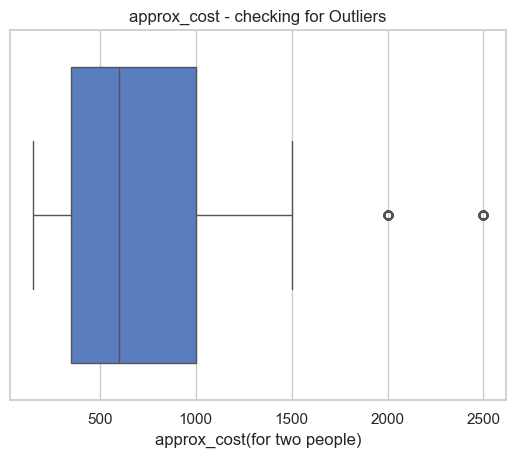

In [ ]:
# checking Outlier's in column "approx_cost(for two people)"

df["approx_cost(for two people)"].describe()

sns.boxplot(x= df["approx_cost(for two people)"])
plt.title('approx_cost - checking for Outliers')
plt.show()

In [ ]:
# Detecting Outliers with IQR Method:

Q1 = df['approx_cost(for two people)'].quantile(0.25)
Q3 = df['approx_cost(for two people)'].quantile(0.75)
IQR = Q3-Q1

print(f'Q1  : ₹{Q1}')
print(f'Q3  : ₹{Q3}')
print(f'IQR : ₹{IQR}')


Q1  : ₹350.0
Q3  : ₹1000.0
IQR : ₹650.0


In [ ]:

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print(f'Lower fence : ₹{lower_fence}')
print(f'Upper fence : ₹{upper_fence}')

# Checking how much Outliers are:

outliers = df[(df['approx_cost(for two people)'] < lower_fence) |
            (df['approx_cost(for two people)'] > upper_fence)]
print(f"Outlier rows : {len(outliers)}")

Lower fence : ₹-625.0
Upper fence : ₹1975.0
Outlier rows : 150


In [ ]:
# saving original column
cost_before = df['approx_cost(for two people)'].copy()

In [ ]:
# Max and Min of column approx_cost(for two people) after caping:

df['approx_cost(for two people)'] = df['approx_cost(for two people)'].clip(
    lower=lower_fence,
    upper=upper_fence)

# saving cost after capping into variable cost_after
cost_after = df['approx_cost(for two people)'].copy()

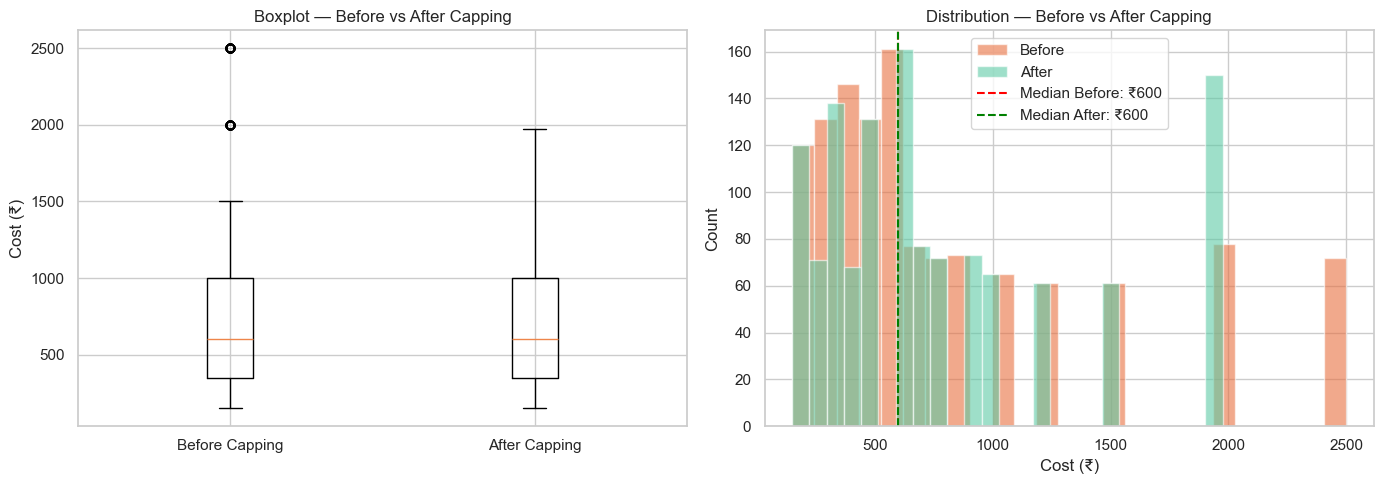

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Chart 1 — BEFORE vs AFTER boxplot ──────────────────────────
axes[0].boxplot([cost_before, cost_after],
                tick_labels=['Before Capping', 'After Capping'])
                
axes[0].set_title('Boxplot — Before vs After Capping')
axes[0].set_ylabel('Cost (₹)')

# ── Chart 2 — BEFORE vs AFTER histogram ────────────────────────
axes[1].hist(cost_before, bins=25,
             color='#E87040', alpha=0.6,
             edgecolor='white', label='Before')
axes[1].hist(cost_after, bins=25,
             color='#5DCAA5', alpha=0.6,
             edgecolor='white', label='After')
axes[1].axvline(cost_before.median(),
                color='red', linestyle='--',
                label=f'Median Before: ₹{cost_before.median():.0f}')
axes[1].axvline(cost_after.median(),
                color='green', linestyle='--',
                label=f'Median After: ₹{cost_after.median():.0f}')
axes[1].set_title('Distribution — Before vs After Capping')
axes[1].set_xlabel('Cost (₹)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# DIFFERENCE 

print(f'Before max : ₹{cost_before.max():.0f}')   
print(f'After max  : ₹{cost_after.max():.0f}')    

print(f'Before mean : ₹{cost_before.mean():.0f}') 
print(f'After mean  : ₹{cost_after.mean():.0f}')

print(f'Before std  : ₹{cost_before.std():.0f}')  
print(f'After std   : ₹{cost_after.std():.0f}')   

Before max : ₹2500
After max  : ₹1975
Before mean : ₹812
After mean  : ₹780
Before std  : ₹630
After std   : ₹553
